# TensorFlow를 활용한 선형회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 선형회귀 문제를 풀어봅니다.

## 주요 단계
1. 데이터 생성 (y = 3x + 2 + 잡음)
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


## 1. 데이터 생성

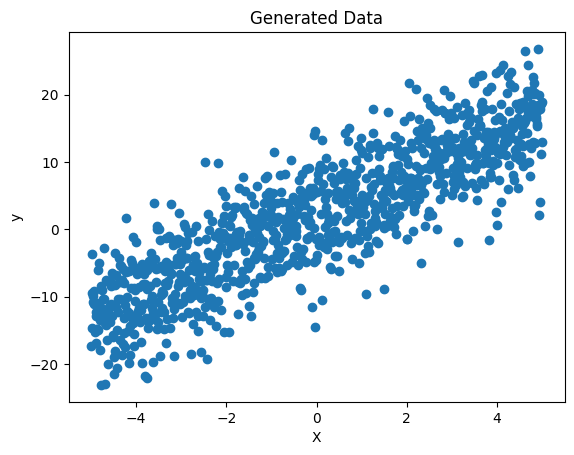

In [8]:
# y = 3x + 2 + noise
n_samples = 1000
X = np.linspace(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)*5

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()

## 2. 모델 정의

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [10]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

## 4. 모델 학습

Epoch 1/200


32/32 - 0s - 4ms/step - loss: 31.5317
Epoch 2/200
32/32 - 0s - 2ms/step - loss: 26.4796
Epoch 3/200
32/32 - 0s - 2ms/step - loss: 25.9983
Epoch 4/200
32/32 - 0s - 1ms/step - loss: 25.8368
Epoch 5/200
32/32 - 0s - 1ms/step - loss: 25.7752
Epoch 6/200
32/32 - 0s - 1ms/step - loss: 25.7561
Epoch 7/200
32/32 - 0s - 1ms/step - loss: 25.7786
Epoch 8/200
32/32 - 0s - 1ms/step - loss: 25.7722
Epoch 9/200
32/32 - 0s - 1ms/step - loss: 25.8147
Epoch 10/200
32/32 - 0s - 1ms/step - loss: 25.7429
Epoch 11/200
32/32 - 0s - 1ms/step - loss: 25.7616
Epoch 12/200
32/32 - 0s - 1ms/step - loss: 25.7825
Epoch 13/200
32/32 - 0s - 1ms/step - loss: 25.7908
Epoch 14/200
32/32 - 0s - 1ms/step - loss: 25.7928
Epoch 15/200
32/32 - 0s - 1ms/step - loss: 25.7950
Epoch 16/200
32/32 - 0s - 1ms/step - loss: 25.7742
Epoch 17/200
32/32 - 0s - 1ms/step - loss: 25.7515
Epoch 18/200
32/32 - 0s - 2ms/step - loss: 25.7743
Epoch 19/200
32/32 - 0s - 2ms/step - loss: 25.7581
Epoch 20/200
32/32 - 0s - 1ms/step - loss: 25.7615
E

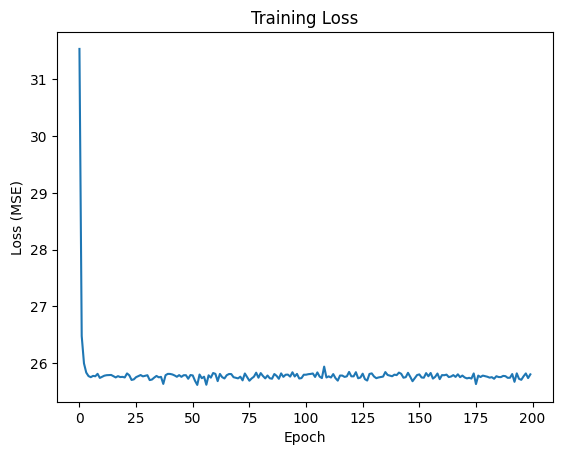

In [11]:
history = model.fit(X, y, epochs=200, verbose=2)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.show()

## 5. 결과 확인

학습된 기울기 W: 2.839, 절편 b: 1.927


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step


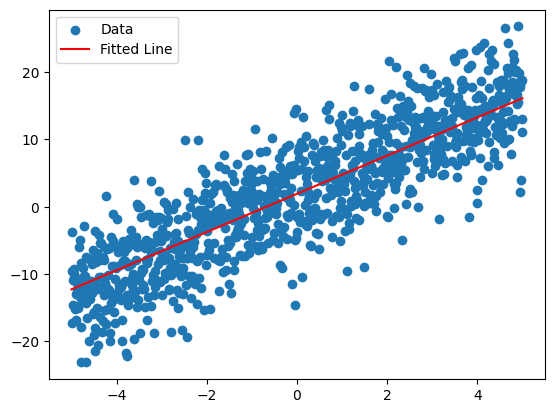

: 

In [ ]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.legend()
plt.show()

## 생각해보기
- 학습 샘플 수가 작아지면 어떻게 되는가?

학습 샘플 수가 지나치게 적어지면(실습의 $n=5$와 같은 경우), 데이터가 전체 모집단의 통계적 특성을 충분히 반영하지 못해 소수의 데이터나 이상치에 모델이 민감하게 반응하는 **과적합(Overfitting)** 및 **높은 분산(High Variance)** 문제가 발생합니다.
특히 경사하강법으로 가중치를 업데이트할 때 단일 샘플의 오차가 전체 기울기(Gradient)에 미치는 영향력이 너무 커져 파라미터 갱신이 크게 요동치며, 결과적으로 본래의 참값($W=3, b=2$)과 동떨어진 엉뚱한 직선으로 수렴할 가능성이 매우 높아집니다.

- 학습 샘플에 잡음이 많으면 어떻게 되는가? 이 경우 학습 데이터가 많이 필요한가?

잡음(Noise)이 커지면 실제 선형 관계식($y=3x+2$)에서 멀리 떨어진 변동이 심해지므로, 모델이 노이즈 성분까지 불필요하게 피팅하려 하거나 최적화 후에도 잔차 제곱합(MSE Loss)이 0에 가깝게 내려가지 못하고 높은 손실값에 머물게 됩니다.
이 경우 **학습 데이터가 훨씬 많이 필요합니다.** 노이즈의 평균이 0인 정규분포를 따른다고 할 때, 샘플 수가 충분히 많아지면 **대수의 법칙(Law of Large Numbers)**에 의해 양과 음의 무작위 오차들이 서로 상쇄(cancel-out)되기 때문입니다. 따라서 데이터셋의 크기를 늘릴수록 노이즈의 영향을 효과적으로 억제하고 원래의 신호(Signal)인 선형 추세를 정확하게 복원할 수 있습니다